# CS224N · Lecture 3 — Neural Net Learning: Gradients by Hand (Matrix Calculus) and Algorithmically (Backpropagation)

**Slides:** [cs224n-spr2024-lecture03-neuralnets.pdf](https://web.stanford.edu/class/cs224n/slides/cs224n-spr2024-lecture03-neuralnets.pdf)

### Key learning
> **The mathematics and practical implementation of how neural networks are trained by backpropagation.**

The lecture says it plainly: *this is the one week of the quarter to work through the readings.* Assignment 2 makes you do the math by hand; after that, PyTorch does it for you. But you need to understand what it's doing to debug models (vanishing/exploding gradients, dead units, shape bugs).

Most of the slides here are equations drawn as images, so the extracted slide text is nearly empty. **Every derivation is written out in full below**, then checked numerically.

| § | Topic | You will implement |
|---|---|---|
| 1 | Recap: the window NER network; non-linearities old and new | Plots of activations and their derivatives |
| 2 | Gradients, Jacobians, the chain rule | Numerical Jacobians to verify each formula |
| 3 | Gradients of the NER network by hand; the shape convention | Full manual-gradient NER classifier, trained |
| 4 | 🔎 Two gradients you'll use forever: sigmoid+BCE and softmax+CE | — |
| 5 | Computation graphs and backpropagation | The lecture's worked example, by hand and in code |
| 6 | Automatic differentiation | A micrograd-style autodiff engine (~60 lines) |
| 7 | The forward/backward API | Layer classes → an MLP that solves the spiral |
| 8 | Gradient checking | Centered vs. one-sided differences |
| 9 | Why understand backprop? | 🔎 Vanishing gradients, dead ReLUs, initialization |
| 10 | PyTorch autograd | Verify our hand gradients against PyTorch |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math, random
from math import erf

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)
random.seed(0)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def softmax(x, axis=-1):
    z = x - x.max(axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)

---
## 1. Where we ended last time

A neural network = running several logistic regressions at the same time, stacked in layers, which lets us re-represent and compose the data, giving a classifier that is highly non-linear in the inputs (but typically linear in the pre-final layer).

**Matrix notation for a layer:** $z = Wx + b$, $a = f(z)$, with $f$ applied element-wise.

**The running example: binary NER, "is the center word a location?"**

$$x = [\,x_{\text{museums}}\ x_{\text{in}}\ x_{\text{Paris}}\ x_{\text{are}}\ x_{\text{amazing}}\,] \in \mathbb{R}^{5d}\quad\text{(embeddings of 1-hot words)}$$
$$z = Wx + b,\qquad h = f(z),\qquad s = u^\top h,\qquad \text{prediction} = \sigma(s) = \frac{1}{1+e^{-s}}$$

### 1.1 Non-linearities, old and new
* **McCulloch & Pitts (1943) threshold unit:** $\mathbb{1}(Wx > \theta) = \mathbb{1}(Wx - \theta > 0)$. This function has **no slope**, so no gradient-based learning.
* **Logistic ("sigmoid")**: $\sigma(z) = 1/(1+e^{-z})$, output in $(0,1)$. Still used to get a probability or a gate (LSTMs, L6).
* **tanh**: just a rescaled and shifted sigmoid, twice as steep, range $[-1,1]$: $\tanh(z) = 2\,\sigma(2z) - 1$.
* **hard tanh**: clip to $[-1, 1]$; cheap.
* **ReLU** (Rectified Linear Unit): $\max(z, 0)$. **For deep networks, the first thing to try.** It trains quickly and performs well due to good gradient backflow (gradient exactly 1 for $z>0$).
* **Leaky ReLU / Parametric ReLU**: a small slope $a z$ for $z<0$, to mitigate ReLU's negative **"dead zone"** (where the gradient is 0 forever).
* **Swish** (arXiv:1710.05941): $x\cdot\sigma(x)$. **GELU** (arXiv:1606.08415): $x\cdot P(X\le x)$ with $X\sim N(0,1)$, i.e. $x\,\Phi(x) \approx x\,\sigma(1.702x)$. GELU/Swish are used in Transformers (BERT, RoBERTa, GPT; 🔎 modern LLMs like LLaMA use **SwiGLU**, a gated Swish variant).

Let's plot them **and their derivatives**: the derivative is what backprop multiplies through the network.

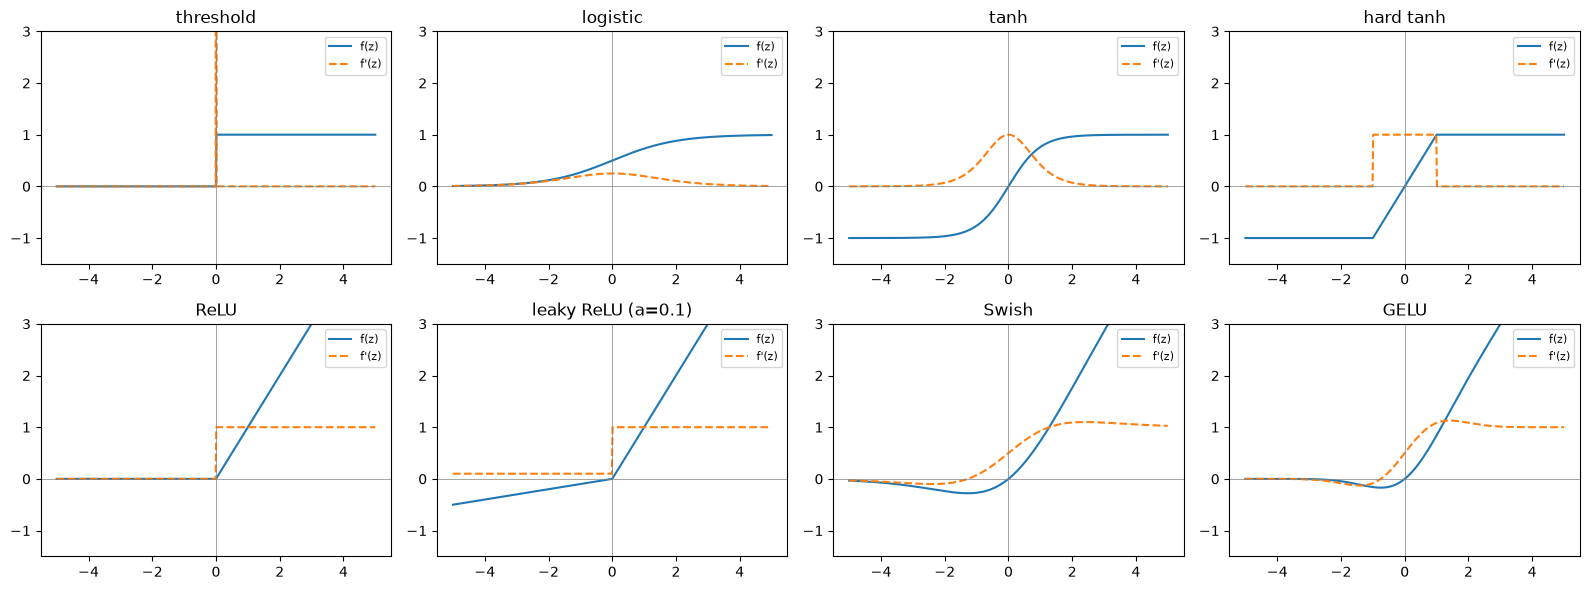

tanh(z) == 2*sigmoid(2z) - 1 : True
max |GELU(z) - z*sigmoid(1.702z)| on [-5,5] = 0.0203
max derivative of logistic = 0.25  <- at most 1/4! (important in Sec. 9)


In [2]:
z = np.linspace(-5, 5, 1001)
Phi = np.vectorize(lambda t: 0.5 * (1 + erf(t / math.sqrt(2))))   # standard normal CDF
acts = {
    "threshold": (z > 0).astype(float),
    "logistic": sigmoid(z),
    "tanh": np.tanh(z),
    "hard tanh": np.clip(z, -1, 1),
    "ReLU": np.maximum(z, 0),
    "leaky ReLU (a=0.1)": np.where(z > 0, z, 0.1 * z),
    "Swish": z * sigmoid(z),
    "GELU": z * Phi(z),
}
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, (name, y) in zip(axes.ravel(), acts.items()):
    dy = np.gradient(y, z)
    ax.plot(z, y, label="f(z)")
    ax.plot(z, dy, "--", label="f'(z)")
    ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
    ax.set_title(name); ax.set_ylim(-1.5, 3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("tanh(z) == 2*sigmoid(2z) - 1 :", np.allclose(np.tanh(z), 2 * sigmoid(2 * z) - 1))
print("max |GELU(z) - z*sigmoid(1.702z)| on [-5,5] =", np.abs(z * Phi(z) - z * sigmoid(1.702 * z)).max().round(4))
print("max derivative of logistic =", (sigmoid(z) * (1 - sigmoid(z))).max(), " <- at most 1/4! (important in Sec. 9)")

**Why non-linearities are needed (recap):** without them, extra layers compile down into a single linear map, $W_1W_2x = Wx$. With them, the network can approximate any complex function.

### 1.2 Remember: stochastic gradient descent
$$\theta^{\text{new}} = \theta^{\text{old}} - \alpha\nabla_\theta J(\theta), \qquad \text{i.e., for each parameter } \theta_j^{\text{new}} = \theta_j^{\text{old}} - \alpha\frac{\partial J(\theta)}{\partial\theta_j^{\text{old}}}$$

**In deep learning, $\theta$ includes the data representation (e.g., word vectors) too!** How can we compute $\nabla_\theta J(\theta)$?
1. **By hand** (matrix calculus, §2–4)
2. **Algorithmically**: the backpropagation algorithm (§5–7)

---
## 2. Computing gradients by hand: matrix calculus

> "Multivariable calculus is just like single-variable calculus if you use matrices."

Fully vectorized gradients are much faster and more useful than non-vectorized ones (though doing a non-vectorized gradient, as in Lecture 1, is good for intuition). The CS224N lecture notes and the "matrix calculus" notes on the syllabus cover this in more detail.

### 2.1 Gradients
**1 output, 1 input:** $f(x) = x^3$ has derivative $\frac{df}{dx} = 3x^2$: *"how much will the output change if we change the input a bit?"*
* At $x=1$ it changes about 3 times as much: $1.01^3 = 1.03$.
* At $x=4$ it changes about 48 times as much: $4.01^3 = 64.48$.

**1 output, $n$ inputs:** $f(x) = f(x_1, \dots, x_n)$. Its **gradient** is the vector of partial derivatives:
$$\frac{\partial f}{\partial x} = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n}\right]$$

In [3]:
for x0 in [1.0, 4.0]:
    print(f"x={x0}: f(x+0.01) = {(x0+0.01)**3:.4f},  f(x) + 0.01 * 3x^2 = {x0**3 + 0.01*3*x0**2:.4f}")

x=1.0: f(x+0.01) = 1.0303,  f(x) + 0.01 * 3x^2 = 1.0300
x=4.0: f(x+0.01) = 64.4812,  f(x) + 0.01 * 3x^2 = 64.4800


### 2.2 The Jacobian: generalizing the gradient
**$m$ outputs, $n$ inputs:** $f(x) = [f_1(x_1..x_n), \dots, f_m(x_1..x_n)]$. Its **Jacobian** is the $m\times n$ matrix of partial derivatives:
$$\frac{\partial f}{\partial x} = \begin{bmatrix} \frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n}\\ \vdots & \ddots & \vdots \\ \frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n}\end{bmatrix}, \qquad \left(\frac{\partial f}{\partial x}\right)_{ij} = \frac{\partial f_i}{\partial x_j}$$

### 2.3 The chain rule
* **One-variable functions: multiply derivatives.** $z = 3y$, $y = x^2$ ⇒ $\frac{dz}{dx} = \frac{dz}{dy}\frac{dy}{dx} = 3\cdot 2x = 6x$.
* **Multi-variable functions: multiply Jacobians.** For $h = f(z)$, $z = Wx + b$:
$$\frac{\partial h}{\partial x} = \frac{\partial h}{\partial z}\,\frac{\partial z}{\partial x}$$

### 2.4 Example Jacobian: an element-wise activation function
$h = f(z)$ with $h_i = f(z_i)$. The function has $n$ outputs and $n$ inputs, so its Jacobian is $n\times n$:
$$\left(\frac{\partial h}{\partial z}\right)_{ij} = \frac{\partial h_i}{\partial z_j} = \frac{\partial}{\partial z_j}f(z_i) = \begin{cases} f'(z_i) & i = j\\ 0 & \text{otherwise}\end{cases}
\qquad\Longrightarrow\qquad \frac{\partial h}{\partial z} = \text{diag}(f'(z))$$

### 2.5 Other Jacobians (the slide says "compute these at home for practice!")
| Function | Jacobian | Why |
|---|---|---|
| $z = Wx + b$, w.r.t. $x$ | $\dfrac{\partial z}{\partial x} = W$ | $z_i = \sum_k W_{ik}x_k + b_i$, so $\partial z_i/\partial x_j = W_{ij}$ |
| $z = Wx + b$, w.r.t. $b$ | $\dfrac{\partial z}{\partial b} = I$ | $\partial z_i/\partial b_j = \mathbb{1}[i=j]$ |
| $s = u^\top h$, w.r.t. $u$ | $\dfrac{\partial s}{\partial u} = h^\top$ | $\partial s/\partial u_j = h_j$ (1×n row: the correct Jacobian; with the *shape convention* (§3.4) we'd write $h$) |
| $s = u^\top h$, w.r.t. $h$ | $\dfrac{\partial s}{\partial h} = u^\top$ | symmetric to the above |

**Never trust a formula you haven't checked.** Let's verify each one with a numerical Jacobian:

In [4]:
def numerical_jacobian(f, x, h=1e-6):
    # J[i, j] = d f_i / d x_j via centered differences. f maps a vector to a vector (or scalar).
    x = x.astype(float)
    fx = np.atleast_1d(f(x))
    J = np.zeros((fx.size, x.size))
    for j in range(x.size):
        e = np.zeros_like(x); e[j] = h
        J[:, j] = (np.atleast_1d(f(x + e)) - np.atleast_1d(f(x - e))) / (2 * h)
    return J

n, m = 3, 4
W, b, x = rng.normal(size=(n, m)), rng.normal(size=n), rng.normal(size=m)
z, u, hvec = rng.normal(size=n), rng.normal(size=n), rng.normal(size=n)

checks = {
    "d tanh(z)/dz = diag(1 - tanh^2 z)": (numerical_jacobian(np.tanh, z), np.diag(1 - np.tanh(z) ** 2)),
    "d(Wx+b)/dx = W": (numerical_jacobian(lambda xx: W @ xx + b, x), W),
    "d(Wx+b)/db = I": (numerical_jacobian(lambda bb: W @ x + bb, b), np.eye(n)),
    "d(u.h)/du = h^T": (numerical_jacobian(lambda uu: uu @ hvec, u), hvec[None, :]),
    "d(u.h)/dh = u^T": (numerical_jacobian(lambda hh: u @ hh, hvec), u[None, :]),
}
for name, (num, ana) in checks.items():
    print(f"{name:38s} matches: {np.allclose(num, ana, atol=1e-6)}")

d tanh(z)/dz = diag(1 - tanh^2 z)      matches: True
d(Wx+b)/dx = W                         matches: True
d(Wx+b)/db = I                         matches: True
d(u.h)/du = h^T                        matches: True
d(u.h)/dh = u^T                        matches: True


---
## 3. Back to our neural net: gradients of the NER network by hand

We'll find $\dfrac{\partial s}{\partial b}$, $\dfrac{\partial s}{\partial W}$, $\dfrac{\partial s}{\partial x}$, $\dfrac{\partial s}{\partial u}$. Really we care about the gradient of the **loss** $J_t$, but we compute the gradient of the score $s$ for simplicity; §4 adds the last step from $s$ to the loss.

### Step 1: Break up the equations into simple pieces
Carefully define your variables and **keep track of their dimensionality!** With $x\in\mathbb{R}^m$ ($m=5d$) and hidden size $n$:

$$s = u^\top h \qquad h = f(z) \qquad z = Wx + b \qquad x \text{ (input)}$$
$$s\in\mathbb{R}\quad u, h, z, b\in\mathbb{R}^{n}\quad W\in\mathbb{R}^{n\times m}\quad x\in\mathbb{R}^m$$

### Step 2: Apply the chain rule
$$\frac{\partial s}{\partial b} = \frac{\partial s}{\partial h}\,\frac{\partial h}{\partial z}\,\frac{\partial z}{\partial b}$$

### Step 3: Write out the Jacobians (from §2.5)
$$\frac{\partial s}{\partial b} = \underbrace{u^\top}_{\partial s/\partial h}\ \underbrace{\text{diag}(f'(z))}_{\partial h/\partial z}\ \underbrace{I}_{\partial z/\partial b} = u^\top\odot f'(z)$$

where $\odot$ is the **Hadamard product** (element-wise multiplication of two vectors to give a vector). Multiplying a row vector by a diagonal matrix just scales each entry: $u^\top\text{diag}(v) = (u\odot v)^\top$.

### 3.1 Re-using computation: the upstream gradient $\delta$
Now suppose we want $\dfrac{\partial s}{\partial W}$. Using the chain rule again:
$$\frac{\partial s}{\partial W} = \frac{\partial s}{\partial h}\frac{\partial h}{\partial z}\frac{\partial z}{\partial W}, \qquad \frac{\partial s}{\partial b} = \frac{\partial s}{\partial h}\frac{\partial h}{\partial z}\frac{\partial z}{\partial b}$$

**The first two factors are the same!** Let's avoid duplicated computation by naming it:
$$\boxed{\delta = \frac{\partial s}{\partial z} = \frac{\partial s}{\partial h}\frac{\partial h}{\partial z} = u^\top\odot f'(z)}$$

$\delta$ is the **upstream gradient** ("error signal") arriving at $z$. Everything below $z$ reuses it: $\dfrac{\partial s}{\partial b} = \delta\dfrac{\partial z}{\partial b} = \delta$, $\dfrac{\partial s}{\partial x} = \delta\dfrac{\partial z}{\partial x} = \delta W$, and so on. **This reuse is the entire idea of backpropagation.**

### 3.2 Derivative with respect to a matrix: output shape
What does $\dfrac{\partial s}{\partial W}$ look like? $W\in\mathbb{R}^{n\times m}$, so there's 1 output and $nm$ inputs: a $1\times nm$ Jacobian? That's inconvenient for the update $\theta^{\text{new}} = \theta^{\text{old}} - \alpha\nabla_\theta J$.

**Instead, we leave pure math and use the shape convention: the shape of the gradient is the shape of the parameters!** So $\dfrac{\partial s}{\partial W}$ is $n\times m$:
$$\frac{\partial s}{\partial W} = \begin{bmatrix}\frac{\partial s}{\partial W_{11}} & \cdots & \frac{\partial s}{\partial W_{1m}}\\ \vdots & \ddots & \vdots\\ \frac{\partial s}{\partial W_{n1}} & \cdots & \frac{\partial s}{\partial W_{nm}}\end{bmatrix}$$

### 3.3 Deriving it: consider a single weight $W_{ij}$
$W_{ij}$ only contributes to $z_i$ (e.g., $W_{23}$ is only used to compute $z_2$, not $z_1$):
$$\frac{\partial z_i}{\partial W_{ij}} = \frac{\partial}{\partial W_{ij}}\left(W_{i\cdot}x + b_i\right) = \frac{\partial}{\partial W_{ij}}\sum_{k=1}^{m}W_{ik}x_k = x_j$$
So $\dfrac{\partial s}{\partial W_{ij}} = \delta_i\,x_j$. Each entry is (error signal at the output unit) × (input signal at the input unit), which is an **outer product**:
$$\boxed{\frac{\partial s}{\partial W} = \delta^\top x^\top}\qquad [n\times 1][1\times m] = n\times m$$
$\delta$ is the upstream gradient (error signal) at $z$, $x$ is the local input signal.

**Why the transposes?** Hacky answer: it makes the dimensions work out (a useful trick for checking your work!). Real answer: each input goes to each output, so you want an outer product.

### 3.4 What shape should derivatives be? Jacobian form vs. shape convention
$\dfrac{\partial s}{\partial b} = u^\top\odot f'(z)$ is a **row** vector in Jacobian form, but the shape convention says it should be a **column** vector, because $b$ is a column vector. There is a disagreement between **Jacobian form** (makes the chain rule easy) and the **shape convention** (makes implementing SGD easy). CS224N assignments expect the **shape convention**. Two ways to work:
1. Use Jacobian form as much as possible, and reshape to the shape convention at the end (what we just did: transpose $\partial s/\partial b$ into a column).
2. Always follow the shape convention: look at dimensions to figure out when to transpose and/or reorder terms. **The error message $\delta$ that arrives at a hidden layer has the same dimensionality as that hidden layer.**

### 3.5 All the gradients of the NER network, in the shape convention
Write $\delta = u\odot f'(z)\in\mathbb{R}^n$ (a column vector now):
$$\frac{\partial s}{\partial u} = h,\qquad \frac{\partial s}{\partial b} = \delta,\qquad \frac{\partial s}{\partial W} = \delta\,x^\top,\qquad \frac{\partial s}{\partial x} = W^\top\delta$$

The last one is the gradient for the **word vectors**. $x$ is the concatenation of 5 word vectors, so we split $W^\top\delta\in\mathbb{R}^{5d}$ into 5 chunks of size $d$ and update each word's row in the embedding matrix. (If a word appears twice in a window, its two chunks **add**.)

Let's implement it and check every gradient numerically:

In [ ]:
def ner_forward_backward(params, win_ids, f="tanh"):
    # Score s for one window, and gradients of s w.r.t. every parameter (shape convention).
    L, W, b, u = params["L"], params["W"], params["b"], params["u"]
    x = L[win_ids].reshape(-1)                 # (5d,)  lookup + concat
    z = W @ x + b                              # (n,)
    if f == "tanh":
        h, fprime = np.tanh(z), 1 - np.tanh(z) ** 2
    else:  # relu
        h, fprime = np.maximum(z, 0), (z > 0).astype(float)
    s = u @ h                                  # scalar

    delta = u * fprime                         # (n,) upstream gradient at z
    grads = {
        "u": h,
        "b": delta,
        "W": np.outer(delta, x),               # delta x^T
    }
    dx = W.T @ delta                           # (5d,) gradient wrt the concatenated window
    dL = np.zeros_like(L)
    np.add.at(dL, win_ids, dx.reshape(len(win_ids), -1))   # split into word chunks, accumulate
    grads["L"] = dL
    return s, grads

d, n_hidden, vocab_n = 3, 4, 10
params = {"L": rng.normal(size=(vocab_n, d)), "W": rng.normal(size=(n_hidden, 5 * d)),
          "b": rng.normal(size=n_hidden), "u": rng.normal(size=n_hidden)}
win = np.array([1, 4, 2, 4, 7])                # word 4 appears twice: its gradients must add

s, grads = ner_forward_backward(params, win)
for name in ["u", "b", "W", "L"]:
    P = params[name]
    num = np.zeros_like(P)
    for idx in np.ndindex(P.shape):
        old = P[idx]
        P[idx] = old + 1e-6; sp, _ = ner_forward_backward(params, win)
        P[idx] = old - 1e-6; sm, _ = ner_forward_backward(params, win)
        P[idx] = old
        num[idx] = (sp - sm) / 2e-6
    print(f"ds/d{name}: shape {grads[name].shape}, max abs error vs numerical = {np.abs(num - grads[name]).max():.2e}")

---
## 4. 🔎 Beyond the slides: the last step, from score to loss

The lecture stops at $\partial s/\partial\theta$. To train, we need $\partial J/\partial\theta = \frac{\partial J}{\partial s}\frac{\partial s}{\partial\theta}$. Two results you will use in nearly every model:

### 4.1 Sigmoid + binary cross-entropy
With label $y\in\{0,1\}$ and $\hat y = \sigma(s)$:
$$J = -\big[y\log\sigma(s) + (1-y)\log(1-\sigma(s))\big]$$
Using $\frac{d}{ds}\log\sigma(s) = 1-\sigma(s)$ and $\frac{d}{ds}\log(1-\sigma(s)) = -\sigma(s)$:
$$\frac{\partial J}{\partial s} = -y(1-\sigma(s)) + (1-y)\sigma(s) = \boxed{\sigma(s) - y}$$

### 4.2 Softmax + cross-entropy
With logits $\theta\in\mathbb{R}^C$, $\hat y = \text{softmax}(\theta)$, one-hot $y$, and $J = -\sum_c y_c\log\hat y_c = -\theta_k + \log\sum_c e^{\theta_c}$ (true class $k$):
$$\frac{\partial J}{\partial\theta_j} = -\mathbb{1}[j=k] + \frac{e^{\theta_j}}{\sum_c e^{\theta_c}} \quad\Longrightarrow\quad \boxed{\frac{\partial J}{\partial\theta} = \hat y - y}$$

**Prediction minus target**, the same expression as word2vec's naive softmax (L1). This is why frameworks fuse softmax and cross-entropy into one op (`nn.CrossEntropyLoss` takes logits): the fused gradient is simple and numerically stable, while computing the softmax Jacobian separately is $C\times C$ and unstable.

So for our NER net trained with BCE: $\delta_{\text{loss}} = (\sigma(s) - y)\cdot(u\odot f'(z))$, and every gradient from §3.5 is multiplied by the scalar $(\sigma(s) - y)$.

In [5]:
# Verify both results numerically.
s0, y0 = 0.7, 1.0
bce = lambda s: -(y0 * np.log(sigmoid(s)) + (1 - y0) * np.log(1 - sigmoid(s)))
print("BCE:  numerical dJ/ds =", round((bce(s0 + 1e-6) - bce(s0 - 1e-6)) / 2e-6, 6), "  sigma(s)-y =", round(sigmoid(s0) - y0, 6))

logits, k = rng.normal(size=5), 2
ce = lambda t: -np.log(softmax(t)[k])
num = numerical_jacobian(ce, logits)[0]
print("CE:   numerical dJ/dtheta =", num.round(6))
print("      y_hat - y           =", (softmax(logits) - np.eye(5)[k]).round(6))

BCE:  numerical dJ/ds = -0.331812   sigma(s)-y = -0.331812
CE:   numerical dJ/dtheta = [ 0.1619  0.319  -0.9068  0.2076  0.2183]
      y_hat - y           = [ 0.1619  0.319  -0.9068  0.2076  0.2183]


### 4.3 Training the NER network with our hand-derived gradients
We now have everything needed to train the Lecture 2 window classifier **with no autodiff at all**. Same toy data idea as in L2 ("paris" is a location in *"in paris ."* but a person in *"paris hilton wowed"*); binary target = "center word is a location". We vectorize the backward pass over a mini-batch: the per-example $\delta$'s become rows of a matrix $\Delta$ and the outer products become one matrix product $\Delta^\top X$.

In [ ]:
people = ["john", "mary", "samuel", "quinn", "alice"]
cities = ["paris", "london", "rome", "tokyo", "lagos"]
def ner_sentence():
    P, P2, C = random.choice(people), random.choice(people), random.choice(cities)
    templates = [
        (f"{P} lives in {C} .", [0, 0, 0, 1, 0]),
        (f"the museums in {C} are amazing to see .", [0, 0, 0, 1, 0, 0, 0, 0, 0]),
        (f"{P} flew to {C} last week .", [0, 0, 0, 1, 0, 0, 0]),
        (f"{P} met {P2} at the hilton hotel in {C} .", [0, 0, 0, 0, 0, 1, 1, 0, 1, 0]),
        ("last night , paris hilton wowed in a sequin gown .", [0] * 11),
        (f"{P} said that {C} is beautiful .", [0, 0, 0, 1, 0, 0, 0]),
    ]
    s, tags = random.choice(templates)
    return s.split(), tags                       # tags: 1 = LOC

def windows(tokens, m=2, pad="<pad>"):
    padded = [pad] * m + tokens + [pad] * m
    return [padded[t:t + 2 * m + 1] for t in range(len(tokens))]

random.seed(1)
data = [ner_sentence() for _ in range(1500)]
words = ["<pad>"] + sorted({w for s, _ in data for w in s})
w2i = {w: i for i, w in enumerate(words)}
Xw = np.array([[w2i[w] for w in win] for s, _ in data for win in windows(s)])
Yw = np.array([t for _, tags in data for t in tags], dtype=float)
n_tr = int(0.8 * len(Xw))
print("windows:", Xw.shape, " fraction LOC:", Yw.mean().round(3))

In [ ]:
def init_params(V, d=16, n=32, seed=0):
    r = np.random.default_rng(seed)
    return {"L": r.normal(scale=0.1, size=(V, d)),
            "W": r.normal(scale=1 / np.sqrt(5 * d), size=(n, 5 * d)),   # Xavier-ish scale (see Sec. 9)
            "b": np.zeros(n),
            "u": r.normal(scale=1 / np.sqrt(n), size=n)}

def batch_forward_backward(p, ids, y):
    B = len(ids)
    X = p["L"][ids].reshape(B, -1)                 # (B, 5d)
    Z = X @ p["W"].T + p["b"]                      # (B, n)
    H = np.tanh(Z)
    S = H @ p["u"]                                 # (B,)
    yhat = sigmoid(S)
    loss = -np.mean(y * np.log(yhat + 1e-12) + (1 - y) * np.log(1 - yhat + 1e-12))
    dS = (yhat - y) / B                            # dJ/ds for each example (Sec. 4.1), averaged
    g = {"u": H.T @ dS}                            # sum_i dS_i * h_i
    Delta = dS[:, None] * p["u"][None, :] * (1 - H ** 2)     # (B, n): rows are delta_i
    g["b"] = Delta.sum(0)
    g["W"] = Delta.T @ X                           # sum of outer products delta_i x_i^T
    dX = Delta @ p["W"]                            # (B, 5d): W^T delta_i for each example
    g["L"] = np.zeros_like(p["L"])
    np.add.at(g["L"], ids.reshape(-1), dX.reshape(-1, p["L"].shape[1]))
    return loss, yhat, g

p = init_params(len(words))
lr = 0.5
for epoch in range(8):
    perm = rng.permutation(n_tr)
    for k in range(0, n_tr, 64):
        idx = perm[k:k + 64]
        loss, _, g = batch_forward_backward(p, Xw[idx], Yw[idx])
        for name in p:
            p[name] -= lr * g[name]
    _, yh, _ = batch_forward_backward(p, Xw[n_tr:], Yw[n_tr:])
    print(f"epoch {epoch+1}: train batch loss {loss:.4f}  held-out accuracy {((yh > 0.5) == Yw[n_tr:]).mean():.4f}")

def p_loc(sentence):
    toks = sentence.split()
    ids = np.array([[w2i.get(w, 0) for w in win] for win in windows(toks)])
    _, yh, _ = batch_forward_backward(p, ids, np.zeros(len(toks)))
    return " ".join(f"{w}({pr:.2f})" for w, pr in zip(toks, yh))

print("\n(The toy task is easy by design. What matters is that the same word 'paris' gets opposite answers from its window.)")
print("P(LOC) per token:")
print(p_loc("last night , paris hilton wowed in a sequin gown ."))
print(p_loc("alice flew to paris last week ."))

---
## 5. Backpropagation

We've almost shown you backpropagation already: it's taking derivatives and using the (generalized, multivariate, matrix) chain rule. **One more concept:** we **re-use** derivatives computed for higher layers when computing derivatives for lower layers, to minimize computation (that's the $\delta$ trick).

### 5.1 Computation graphs
Software represents our neural net equations as a **graph**:
* **source nodes**: inputs (and parameters)
* **interior nodes**: operations
* **edges** pass along the result of the operation

For our network $s = u^\top f(Wx + b)$: `x, W → (*) → (+ b) → f → (· u) → s`.

**Forward propagation**: evaluate the graph from inputs to output. **Backpropagation**: go backwards along edges, passing along gradients.

### 5.2 Backprop at a single node
* A node receives an **upstream gradient** $\frac{\partial s}{\partial h}$ (how the final output depends on this node's output).
* The goal is to pass on the correct **downstream gradient** $\frac{\partial s}{\partial z}$ (how the output depends on this node's input).
* Each node has a **local gradient** $\frac{\partial h}{\partial z}$, the gradient of its output w.r.t. its input.
* **Chain rule:**
$$\boxed{[\text{downstream gradient}] = [\text{upstream gradient}] \times [\text{local gradient}]}$$
* **Multiple inputs → multiple local gradients**, one per input. A node $z = Wx$ passes $\frac{\partial s}{\partial z}\frac{\partial z}{\partial W}$ to $W$ and $\frac{\partial s}{\partial z}\frac{\partial z}{\partial x}$ to $x$.

### 5.3 The lecture's worked example
$$f(x, y, z) = (x + y)\,\max(y, z),\qquad x = 1,\ y = 2,\ z = 0$$

**Forward prop steps:** $a = x + y = 3$, $\ b = \max(y, z) = 2$, $\ f = ab = 6$.

**Local gradients:**
* $a = x+y$: $\ \frac{\partial a}{\partial x} = 1$, $\frac{\partial a}{\partial y} = 1$
* $b = \max(y,z)$: $\ \frac{\partial b}{\partial y} = \mathbb{1}(y>z) = 1$, $\frac{\partial b}{\partial z} = \mathbb{1}(z>y) = 0$
* $f = ab$: $\ \frac{\partial f}{\partial a} = b = 2$, $\frac{\partial f}{\partial b} = a = 3$

**Backward (upstream × local = downstream)**, starting with $\frac{\partial f}{\partial f} = 1$:
* into the `*` node: $\frac{\partial f}{\partial a} = 1\cdot2 = 2$, $\ \frac{\partial f}{\partial b} = 1\cdot3 = 3$
* into `max`: $\frac{\partial f}{\partial y}\big|_{\text{via }b} = 3\cdot1 = 3$, $\ \frac{\partial f}{\partial z} = 3\cdot0 = 0$
* into `+`: $\frac{\partial f}{\partial x} = 2\cdot1 = 2$, $\ \frac{\partial f}{\partial y}\big|_{\text{via }a} = 2\cdot1 = 2$

**Gradients sum at outward branches.** $y$ feeds into *two* nodes, so its total gradient is the sum: $\frac{\partial f}{\partial y} = 2 + 3 = 5$. (This is the multivariable chain rule: $\frac{\partial f}{\partial y} = \frac{\partial f}{\partial a}\frac{\partial a}{\partial y} + \frac{\partial f}{\partial b}\frac{\partial b}{\partial y}$.)

**Final:** $\frac{\partial f}{\partial x} = 2$, $\frac{\partial f}{\partial y} = 5$, $\frac{\partial f}{\partial z} = 0$.

### 5.4 Node intuitions
* **`+` "distributes"** the upstream gradient to each summand (local gradient is 1).
* **`max` "routes"** the upstream gradient to whichever input was largest (the others get 0). This is why ReLU = max(z, 0) has "dead" units.
* **`*` "switches"** the upstream gradient: each input gets the upstream gradient times *the other* input's value.

In [ ]:
# The worked example, by hand, step by step.
x, y, zz = 1.0, 2.0, 0.0
a = x + y;  b_ = max(y, zz);  f = a * b_                          # forward
df = 1.0
df_da, df_db = df * b_, df * a                                    # '*' switches
df_dy_via_b, df_dz = df_db * (y > zz), df_db * (zz > y)           # 'max' routes
df_dx, df_dy_via_a = df_da * 1.0, df_da * 1.0                     # '+' distributes
df_dy = df_dy_via_a + df_dy_via_b                                 # gradients sum at branches
print(f"forward: a={a}, b={b_}, f={f}")
print(f"df/dx = {df_dx}, df/dy = {df_dy}, df/dz = {float(df_dz)}")

# Numerical check
F = lambda x, y, z: (x + y) * max(y, z)
h = 1e-6
print("numerical:", [(F(x+h,y,zz)-F(x-h,y,zz))/(2*h), (F(x,y+h,zz)-F(x,y-h,zz))/(2*h), (F(x,y,zz+h)-F(x,y,zz-h))/(2*h)])

### 5.5 Efficiency: compute all gradients at once
**Incorrect way:** first compute $\frac{\partial s}{\partial b}$, then independently compute $\frac{\partial s}{\partial W}$. That's duplicated computation (both pass through $\frac{\partial s}{\partial h}\frac{\partial h}{\partial z}$).

**Correct way:** compute all the gradients at once in one backward sweep, analogous to using $\delta$ when we computed gradients by hand.

### 5.6 Backprop in a general computation graph
1. **Fprop:** visit nodes in **topological sort** order. Compute the value of each node given its predecessors.
2. **Bprop:** initialize the output gradient = 1. Visit nodes in **reverse** order, and compute the gradient w.r.t. each node using the gradients w.r.t. its successors:
$$\frac{\partial z}{\partial x} = \sum_{y_i\in\text{successors}(x)}\frac{\partial z}{\partial y_i}\frac{\partial y_i}{\partial x}$$

**Done correctly, the big-O complexity of fprop and bprop is the same.** (🔎 This is *reverse-mode* automatic differentiation. It's efficient because we have one scalar output and millions of inputs. *Forward-mode* AD would need one pass per input.) In general our nets have a regular layer structure, so we can use matrices and Jacobians.

### 5.7 Automatic differentiation
* The gradient computation can be **automatically inferred** from the symbolic expression of the fprop.
* Each node type needs to know how to compute its output, and how to compute the gradient w.r.t. its inputs given the gradient w.r.t. its output.
* Modern DL frameworks (TensorFlow, PyTorch, JAX) do backpropagation for you, but mainly leave the layer/node writer to hand-calculate the local derivative.

---
## 6. 🔎 Build your own autodiff engine (micrograd-style)

The best way to truly understand backprop is to implement it. Below is a complete reverse-mode autodiff engine for scalars in ~60 lines, in the spirit of Andrej Karpathy's *micrograd*. Each `Value` remembers its parents and a `_backward` closure that applies **upstream × local** to each parent, accumulating with `+=` (gradients sum at branches). `backward()` does a **topological sort** and visits nodes in reverse: exactly §5.6.

In [6]:
class Value:
    # A scalar node in a computation graph, with reverse-mode autodiff.
    def __init__(self, data, parents=(), op=""):
        self.data, self.grad = float(data), 0.0
        self._parents, self._op = parents, op
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():                       # '+' distributes
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():                       # '*' switches
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def max(self, other):
        out = Value(max(self.data, other.data), (self, other), "max")
        def _backward():                       # 'max' routes
            if self.data >= other.data: self.grad += out.grad
            else:                       other.grad += out.grad
        out._backward = _backward
        return out

    def __pow__(self, k):
        out = Value(self.data ** k, (self,), f"**{k}")
        def _backward(): self.grad += k * self.data ** (k - 1) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), "tanh")
        def _backward(): self.grad += (1 - t * t) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), "exp")
        def _backward(): self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def log(self):
        out = Value(math.log(self.data), (self,), "log")
        def _backward(): self.grad += (1 / self.data) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        return self.max(Value(0.0))

    # convenience operators built from the primitives above
    def __neg__(self):            return self * -1
    def __sub__(self, other):     return self + (-other if isinstance(other, Value) else -other)
    def __truediv__(self, other): return self * (other if isinstance(other, Value) else Value(other)) ** -1
    __radd__ = __add__
    __rmul__ = __mul__
    def __rsub__(self, other):    return Value(other) - self
    def __rtruediv__(self, other): return Value(other) * self ** -1

    def backward(self):
        topo, seen = [], set()
        def build(v):                          # topological sort (DFS post-order)
            if v not in seen:
                seen.add(v)
                for p_ in v._parents:
                    build(p_)
                topo.append(v)
        build(self)
        self.grad = 1.0                        # d out / d out = 1
        for v in reversed(topo):               # reverse topological order
            v._backward()

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

# The lecture example again, now fully automatic:
x, y, z = Value(1.0), Value(2.0), Value(0.0)
f = (x + y) * y.max(z)
f.backward()
print("f =", f.data, "| df/dx =", x.grad, " df/dy =", y.grad, " df/dz =", z.grad)

f = 6.0 | df/dx = 2.0  df/dy = 5.0  df/dz = 0.0


In [7]:
# A neuron with a sigmoid built from primitives; check against the analytic formula.
w1, w2, bb = Value(0.5), Value(-1.5), Value(0.1)
x1, x2 = Value(2.0), Value(1.0)
zv = w1 * x1 + w2 * x2 + bb
sig = 1 / (1 + (-zv).exp())                    # sigmoid from exp, +, /
loss = -(sig.log())                            # -log sigma(z): BCE with y=1
loss.backward()
s_ = sigmoid(zv.data)
print(f"autodiff dL/dw1 = {w1.grad:.6f}   analytic (sigma(z)-1)*x1 = {(s_ - 1) * 2.0:.6f}")
print(f"autodiff dL/db  = {bb.grad:.6f}   analytic (sigma(z)-1)    = {s_ - 1:.6f}")

autodiff dL/dw1 = -1.197375   analytic (sigma(z)-1)*x1 = -1.197375
autodiff dL/db  = -0.598688   analytic (sigma(z)-1)    = -0.598688


Our engine can train a real (tiny) network. Here's a 2-layer MLP learning **XOR**, the classic problem that no linear classifier can solve (and the reason non-linearities matter):

In [ ]:
class Neuron:
    def __init__(self, n_in, act=True):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(n_in)]
        self.b = Value(0.0)
        self.act = act
    def __call__(self, xs):
        out = sum((wi * xi for wi, xi in zip(self.w, xs)), self.b)
        return out.tanh() if self.act else out
    def parameters(self):
        return self.w + [self.b]

class MLP:
    def __init__(self, sizes):
        self.layers = [[Neuron(sizes[i], act=(i < len(sizes) - 2)) for _ in range(sizes[i + 1])]
                       for i in range(len(sizes) - 1)]
    def __call__(self, xs):
        for layer in self.layers:
            xs = [neuron(xs) for neuron in layer]
        return xs[0] if len(xs) == 1 else xs
    def parameters(self):
        return [p_ for layer in self.layers for n_ in layer for p_ in n_.parameters()]

random.seed(3)
net = MLP([2, 4, 1])
X_xor = [[0, 0], [0, 1], [1, 0], [1, 1]]
Y_xor = [0, 1, 1, 0]
for step in range(300):
    total = Value(0.0)
    for xs, yt in zip(X_xor, Y_xor):
        logit = net([Value(v) for v in xs])
        prob = 1 / (1 + (-logit).exp())
        total = total + -(yt * prob.log() + (1 - yt) * (1 - prob).log())   # BCE
    for p_ in net.parameters():
        p_.grad = 0.0                      # zero grads (like optimizer.zero_grad())
    total.backward()
    for p_ in net.parameters():
        p_.data -= 0.2 * p_.grad
    if step % 75 == 0 or step == 299:
        print(f"step {step:3d}  loss {total.data:.4f}")

for xs, yt in zip(X_xor, Y_xor):
    logit = net([Value(v) for v in xs])
    print(f"XOR{tuple(xs)} = {yt}   predicted P(1) = {sigmoid(logit.data):.3f}")

Note the `p.grad = 0.0` before each `backward()`. Because gradients **accumulate** (`+=`, needed for branches), you must reset them every step. This is exactly why PyTorch requires `optimizer.zero_grad()`, and forgetting it is one of the most common PyTorch bugs.

---
## 7. The forward/backward API (how real frameworks are organized)

Scalar autodiff is beautiful but slow. Real frameworks operate on **tensors**, and each layer type implements a pair of methods (the slides show this as the "forward/backward API"):
* `forward(inputs)`: compute the output, **saving** whatever the backward pass will need (here, the inputs).
* `backward(upstream_grad)`: return the downstream gradient(s) using the saved values, and store gradients for any parameters.

The simplest example, from the slides, is a multiply gate $z = xy$:

In [ ]:
class MultiplyGate:
    def forward(self, x, y):
        self.x, self.y = x, y          # must remember inputs for backward!
        return x * y
    def backward(self, dz):
        dx = self.y * dz               # [dz/dx * dL/dz]
        dy = self.x * dz               # [dz/dy * dL/dz]
        return dx, dy

g = MultiplyGate()
print("forward:", g.forward(3.0, -4.0), " backward(dz=2):", g.backward(2.0))

Now full layers, vectorized over a mini-batch. These derivations are §3 in batch form: for $Z = XW^\top + b$ (one example per row of $X$), with upstream gradient $G = \partial J/\partial Z$:
$$\frac{\partial J}{\partial W} = G^\top X,\qquad \frac{\partial J}{\partial b} = \textstyle\sum_{\text{rows}} G,\qquad \frac{\partial J}{\partial X} = G\,W$$

In [ ]:
class Linear:
    def __init__(self, n_in, n_out, rng):
        self.W = rng.normal(scale=np.sqrt(2.0 / n_in), size=(n_out, n_in))   # He init (Sec. 9)
        self.b = np.zeros(n_out)
    def forward(self, X):
        self.X = X
        return X @ self.W.T + self.b
    def backward(self, G):
        self.dW = G.T @ self.X
        self.db = G.sum(0)
        return G @ self.W
    def params(self):
        return [(self.W, "dW"), (self.b, "db")]

class ReLU:
    def forward(self, Z):
        self.mask = Z > 0
        return Z * self.mask
    def backward(self, G):
        return G * self.mask                   # max "routes": gradient flows only where Z > 0
    def params(self):
        return []

class Tanh:
    def forward(self, Z):
        self.H = np.tanh(Z)
        return self.H
    def backward(self, G):
        return G * (1 - self.H ** 2)           # diag(f'(z)) applied as an elementwise product
    def params(self):
        return []

class SoftmaxCrossEntropy:
    # Fused softmax + cross-entropy: backward is (Y_hat - Y) / B (Sec. 4.2).
    def forward(self, logits, y):
        self.P = softmax(logits, axis=1)
        self.y = y
        return -np.mean(np.log(self.P[np.arange(len(y)), y] + 1e-12))
    def backward(self):
        G = self.P.copy()
        G[np.arange(len(self.y)), self.y] -= 1
        return G / len(self.y)

class Sequential:
    def __init__(self, *layers):
        self.layers = layers
    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X
    def backward(self, G):
        for layer in reversed(self.layers):    # reverse order = reverse topological order
            G = layer.backward(G)
        return G
    def step(self, lr):
        for layer in self.layers:
            for P, gname in layer.params():
                P -= lr * getattr(layer, gname)

**Check the layered implementation numerically** before using it (§8 explains the method):

In [ ]:
r = np.random.default_rng(1)
mlp = Sequential(Linear(2, 5, r), Tanh(), Linear(5, 3, r))
lossf = SoftmaxCrossEntropy()
Xc, yc = r.normal(size=(4, 2)), np.array([0, 2, 1, 2])
lossf.forward(mlp.forward(Xc), yc)
mlp.backward(lossf.backward())
for li, layer in enumerate(mlp.layers):
    for P, gname in layer.params():
        num = np.zeros_like(P)
        for idx in np.ndindex(P.shape):
            old = P[idx]
            P[idx] = old + 1e-6; lp = lossf.forward(mlp.forward(Xc), yc)
            P[idx] = old - 1e-6; lm = lossf.forward(mlp.forward(Xc), yc)
            P[idx] = old
            num[idx] = (lp - lm) / 2e-6
        g_ = getattr(layer, gname)
        print(f"layer {li} {gname}: relative error {np.max(np.abs(num - g_) / (np.abs(num) + np.abs(g_) + 1e-12)):.2e}")

Now the payoff. In Lecture 2 a linear softmax classifier only reached ~50% on the 3-class spiral. With one hidden ReLU layer, trained with **our own backprop**:

In [ ]:
def make_spiral(n=100, C=3, seed=0):
    r = np.random.default_rng(seed)
    Xs, ys = [], []
    for c in range(C):
        rad = np.linspace(0.05, 1, n)
        ang = np.linspace(c * 4, (c + 1) * 4, n) + r.normal(scale=0.2, size=n)
        Xs.append(np.c_[rad * np.sin(ang), rad * np.cos(ang)]); ys.append(np.full(n, c))
    return np.vstack(Xs), np.concatenate(ys)

Xsp, ysp = make_spiral()
r = np.random.default_rng(0)
model = Sequential(Linear(2, 100, r), ReLU(), Linear(100, 3, r))
lossf = SoftmaxCrossEntropy()
for step in range(3000):
    loss = lossf.forward(model.forward(Xsp), ysp)
    model.backward(lossf.backward())
    model.step(lr=0.5)
    if step % 1000 == 0:
        print(f"step {step}: loss {loss:.4f}")
acc = (model.forward(Xsp).argmax(1) == ysp).mean()

gx, gy = np.meshgrid(np.linspace(-1.1, 1.1, 300), np.linspace(-1.1, 1.1, 300))
pred = model.forward(np.c_[gx.ravel(), gy.ravel()]).argmax(1).reshape(gx.shape)
plt.figure(figsize=(5, 5))
plt.contourf(gx, gy, pred, alpha=0.3, cmap="brg")
plt.scatter(Xsp[:, 0], Xsp[:, 1], c=ysp, cmap="brg", s=10)
plt.title(f"1-hidden-layer ReLU net, hand-written backprop\ntrain accuracy {acc:.0%}"); plt.show()

---
## 8. Manual gradient checking: the numeric gradient

$$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}\qquad\text{for small } h\ (\approx 10^{-4})$$

* Easy to implement correctly.
* But approximate and **very slow**: you have to recompute $f$ for every parameter of the model (2 forward passes per parameter).
* Useful for checking your implementation. In the old days, when we hand-wrote everything, doing this everywhere was the key test. Now it's much less needed, but you can use it to check layers are correctly implemented (as we did above).

🔎 **Practical details:**
* Use the **centered** difference: its error is $O(h^2)$, while the one-sided $\frac{f(x+h)-f(x)}{h}$ has error $O(h)$.
* Don't make $h$ too small: floating-point **cancellation** error grows like $\epsilon_{\text{machine}}/h$.
* Compare with **relative error** $\frac{|a-b|}{|a|+|b|}$. In float64: below $10^{-7}$ is great; above $10^{-4}$ means something is probably wrong (unless there are kinks like ReLU at 0).
* Check in **float64**, on a small network, with a few random inputs; turn off dropout and other randomness.
* PyTorch has this built in: `torch.autograd.gradcheck`.

In [ ]:
fx = lambda t: np.sin(t) * np.exp(t)
dfx = lambda t: np.exp(t) * (np.sin(t) + np.cos(t))
x0 = 0.7
hs = np.logspace(-12, -1, 60)
err_fwd = [abs((fx(x0 + h) - fx(x0)) / h - dfx(x0)) for h in hs]
err_ctr = [abs((fx(x0 + h) - fx(x0 - h)) / (2 * h) - dfx(x0)) for h in hs]
plt.figure(figsize=(6, 4))
plt.loglog(hs, err_fwd, label="one-sided  (error ~ h)")
plt.loglog(hs, err_ctr, label="centered   (error ~ h^2)")
plt.xlabel("h"); plt.ylabel("absolute error"); plt.legend()
plt.title("Numeric gradient error: truncation (right) vs. round-off (left)"); plt.show()
for h in [1e-2, 1e-4, 1e-6]:
    print(f"h={h:.0e}:  one-sided error {abs((fx(x0+h)-fx(x0))/h - dfx(x0)):.1e}   centered error {abs((fx(x0+h)-fx(x0-h))/(2*h) - dfx(x0)):.1e}")

---
## 9. Why learn all these details about gradients?

Modern deep learning frameworks compute gradients for you! But why take a class on compilers or systems when they're implemented for you? **Understanding what is going on under the hood is useful.** Backpropagation doesn't always work perfectly out of the box, and understanding why is crucial for debugging and improving models. (See Karpathy, *Yes you should understand backprop*.) The example the lecture previews: **exploding and vanishing gradients** (Lecture 6 covers this for RNNs).

### 🔎 9.1 Vanishing gradients, seen through the chain rule
Backprop multiplies one local Jacobian per layer. For a deep stack $h_\ell = f(W_\ell h_{\ell-1})$:
$$\frac{\partial J}{\partial h_0} = W_1^\top\text{diag}(f'(z_1))\,W_2^\top\text{diag}(f'(z_2))\cdots W_L^\top\text{diag}(f'(z_L))\,\frac{\partial J}{\partial h_L}$$
* The logistic's derivative is **at most 1/4**. Twenty such factors shrink the gradient by up to $4^{-20}\approx10^{-12}$: the **vanishing gradient** problem.
* If the weights are too large, the product can instead **explode**.
* **ReLU** has derivative exactly 1 on its active side, which is a big reason it trains deep nets well ("good gradient backflow").

### 🔎 9.2 Initialization keeps signals and gradients at a healthy scale
* **Xavier/Glorot** (for tanh/sigmoid): $\text{Var}(W_{ij}) = \frac{2}{n_{\text{in}} + n_{\text{out}}}$ (often simply $1/n_{\text{in}}$).
* **He/Kaiming** (for ReLU, which zeroes half its inputs): $\text{Var}(W_{ij}) = \frac{2}{n_{\text{in}}}$.

Let's measure the gradient norm arriving at each layer of a 20-layer network:

In [ ]:
def grad_norms(act, init_std, depth=20, width=100, seed=0):
    r = np.random.default_rng(seed)
    Ws = [r.normal(scale=init_std(width), size=(width, width)) for _ in range(depth)]
    h, cache = r.normal(size=(64, width)), []
    for W in Ws:                                  # forward
        z = h @ W.T
        h = {"sigmoid": sigmoid, "tanh": np.tanh, "relu": lambda v: np.maximum(v, 0)}[act](z)
        cache.append((z, h))
    G, norms = np.ones_like(h) / h.size, []
    for W, (z, h) in zip(reversed(Ws), reversed(cache)):   # backward
        fprime = {"sigmoid": h * (1 - h), "tanh": 1 - h ** 2, "relu": (z > 0).astype(float)}[act]
        G = (G * fprime) @ W
        norms.append(np.linalg.norm(G))
    return norms[::-1]                            # index 0 = first layer

configs = {
    "sigmoid, std=0.01 (naive)": ("sigmoid", lambda n: 0.01),
    "sigmoid, Xavier": ("sigmoid", lambda n: np.sqrt(1 / n)),
    "tanh, Xavier": ("tanh", lambda n: np.sqrt(1 / n)),
    "ReLU, std=0.01 (naive)": ("relu", lambda n: 0.01),
    "ReLU, He": ("relu", lambda n: np.sqrt(2 / n)),
    "ReLU, std too large": ("relu", lambda n: np.sqrt(4 / n)),
}
plt.figure(figsize=(8, 5))
for name, (act, init) in configs.items():
    plt.semilogy(range(1, 21), grad_norms(act, init), "o-", ms=3, label=name)
plt.xlabel("layer (1 = closest to the input)"); plt.ylabel("gradient norm at layer")
plt.title("Gradient flow through 20 layers"); plt.legend(fontsize=8); plt.show()

for name, (act, init) in configs.items():
    g_ = grad_norms(act, init)
    print(f"{name:27s} gradient norm at layer 1 / layer 20 = {g_[0] / g_[-1]:.1e}")

Read the plot from right (output) to left (input). With naive init, the gradient reaching the first layer is 20–30 orders of magnitude smaller than at the top, so the early layers effectively don't learn. **Even with Xavier init, sigmoid loses ~12 orders of magnitude**, which is about $(1/4)^{20}$, the derivative bound from §1.1. Too large an init explodes instead (~1000×). **He init + ReLU keeps it roughly flat.** Later lectures add more tools for this: residual connections and layer normalization (L6, L8).

### 🔎 9.3 Dead ReLUs
If a ReLU unit's pre-activation is negative for *every* input (e.g., after a large update pushed its bias very negative), its local gradient is 0 everywhere ("max routes" nothing back), so it can never recover. Remedies: sensible learning rates and init, Leaky ReLU / GELU.

In [ ]:
r = np.random.default_rng(0)
Xd = r.normal(size=(1000, 10))
Wd = r.normal(scale=np.sqrt(2 / 10), size=(50, 10))
for bias in [0.0, -2.0, -5.0]:
    active = (Xd @ Wd.T + bias > 0)
    dead = (~active.any(axis=0)).mean()
    print(f"bias {bias:+.0f}: fraction of ReLU units dead on ALL 1000 inputs = {dead:.0%}")

---
## 10. PyTorch autograd: let the software do it

PyTorch builds the computation graph dynamically as you run the forward pass (every tensor with `requires_grad=True` records the op that produced it), then `.backward()` runs reverse-mode autodiff, exactly what our `Value` class does, but over tensors and on GPUs.

Let's verify that PyTorch's gradients equal our hand-derived NER gradients from §3.5:

In [ ]:
# [PyTorch] Autograd vs. our hand-derived gradients.
import torch

torch.manual_seed(0)
P_np = {k: v.copy() for k, v in params.items()}         # the small NER params from Sec. 3
P_t = {k: torch.tensor(v, requires_grad=True) for k, v in P_np.items()}
win_t = torch.tensor(win)

x_t = P_t["L"][win_t].reshape(-1)                       # lookup + concat
s_t = P_t["u"] @ torch.tanh(P_t["W"] @ x_t + P_t["b"])
s_t.backward()

_, grads_np = ner_forward_backward(P_np, win)
for k in ["u", "b", "W", "L"]:
    print(f"d s / d {k}: max |autograd - by hand| = {np.abs(P_t[k].grad.numpy() - grads_np[k]).max():.2e}")

# The lecture's example graph in PyTorch:
x, y, z = (torch.tensor(v, requires_grad=True) for v in (1.0, 2.0, 0.0))
f = (x + y) * torch.maximum(y, z)
f.backward()
print("torch: df/dx =", x.grad.item(), " df/dy =", y.grad.item(), " df/dz =", z.grad.item())

# Built-in gradient checker (needs float64):
lin = torch.nn.Linear(4, 3).double()
inp = torch.randn(2, 4, dtype=torch.float64, requires_grad=True)
print("gradcheck passes:", torch.autograd.gradcheck(lambda t: torch.tanh(lin(t)), (inp,)))

---
## 11. Summary

**We've mastered the core technology of neural nets! 🎉**

* **Backpropagation:** recursively (and hence efficiently) apply the chain rule along the computation graph.
* $[\text{downstream gradient}] = [\text{upstream gradient}]\times[\text{local gradient}]$
* **Forward pass:** compute the results of operations and save intermediate values.
* **Backward pass:** apply the chain rule to compute gradients, in reverse topological order; gradients **sum** at branches.

| Formula | Meaning |
|---|---|
| $\partial h/\partial z = \text{diag}(f'(z))$ | Element-wise activation Jacobian |
| $\partial (Wx+b)/\partial x = W$, $\ \partial/\partial b = I$ | Linear layer Jacobians |
| $\delta = \partial s/\partial z = u\odot f'(z)$ | Upstream gradient ("error signal"), reused by everything below |
| $\partial s/\partial W = \delta x^\top$, $\ \partial s/\partial x = W^\top\delta$ | Outer product for weights; transpose to pass down |
| $\partial J/\partial s = \sigma(s) - y$ | Sigmoid + BCE |
| $\partial J/\partial\theta = \hat y - y$ | Softmax + cross-entropy |
| Shape convention | Gradient has the same shape as the parameter |

### Exercises
1. Derive $\partial s/\partial x$ and $\partial s/\partial u$ for the NER net in Jacobian form, then convert to the shape convention.
2. Add `Sigmoid` and `LeakyReLU` layers to the forward/backward API and gradient-check them.
3. Extend the `Value` class with `sigmoid()` as a *single* primitive (with its own `_backward`) and confirm it matches the composed version.
4. In §4.3, replace `tanh` with ReLU (remember to change the derivative). Does it train faster?
5. In §9, add a "residual" connection $h_\ell = h_{\ell-1} + f(W_\ell h_{\ell-1})$ and replot. What happens to the gradient norms, and why? (Hint: what is the Jacobian of the identity path?)

### References
* CS224N lecture notes on backpropagation, and *Computing Neural Network Gradients* (Kevin Clark), on the syllabus.
* Karpathy, *Yes you should understand backprop* (2016), and the *micrograd* repository.
* Goodfellow, Bengio & Courville, *Deep Learning*, Ch. 6.5 (back-propagation).
* Glorot & Bengio 2010 (Xavier init); He et al. 2015 (He init).
* Baydin et al. 2018, *Automatic Differentiation in Machine Learning: a Survey*.

**Next:** Lecture 4, dependency parsing, where we use exactly this machinery to build a neural parser.